# Generate maps for neighbourhoods

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.affinity import rotate
from shapely.ops import unary_union
import contextily as ctx
from shapely.geometry import box
from shapely.affinity import rotate
from shapely.ops import unary_union
from matplotlib.patches import PathPatch
from matplotlib.path import Path
import numpy as np
from shapely.affinity import translate, rotate

In [ ]:
gdf = gpd.read_file('./data/neighbourhoods/neighbourhoods.geojson')
gdf = gdf.to_crs(epsg=32617)

In [7]:
#TEMP: Hard code neighbourhood to use
hood = "Rexdale-Kipling"

Entire Toronto map with neighbourhood highlighted

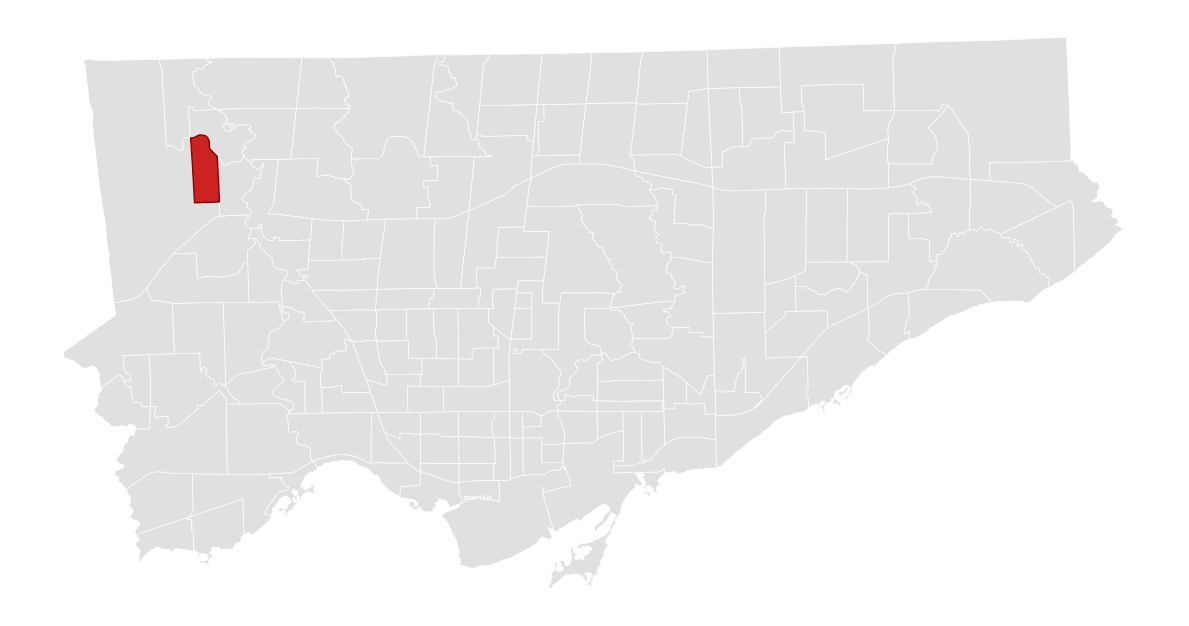

In [9]:
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

# Rotate geometry around the centroid of the whole city
city_centroid = unary_union(gdf.geometry).centroid
gdf_rotated = gdf.copy()
gdf_rotated['geometry'] = gdf.geometry.apply(
    lambda geom: rotate(geom, -17, origin=city_centroid)
)

gdf_rotated.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.5)
gdf_rotated[gdf_rotated["AREA_NAME"] == hood].plot(
    ax=ax,
    color="#cc2222",
    edgecolor="#880000",
    linewidth=1
)
ax.set_axis_off()
plt.tight_layout()

# plt.savefig(f"{hood}_map.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

Close up of neighbourhood

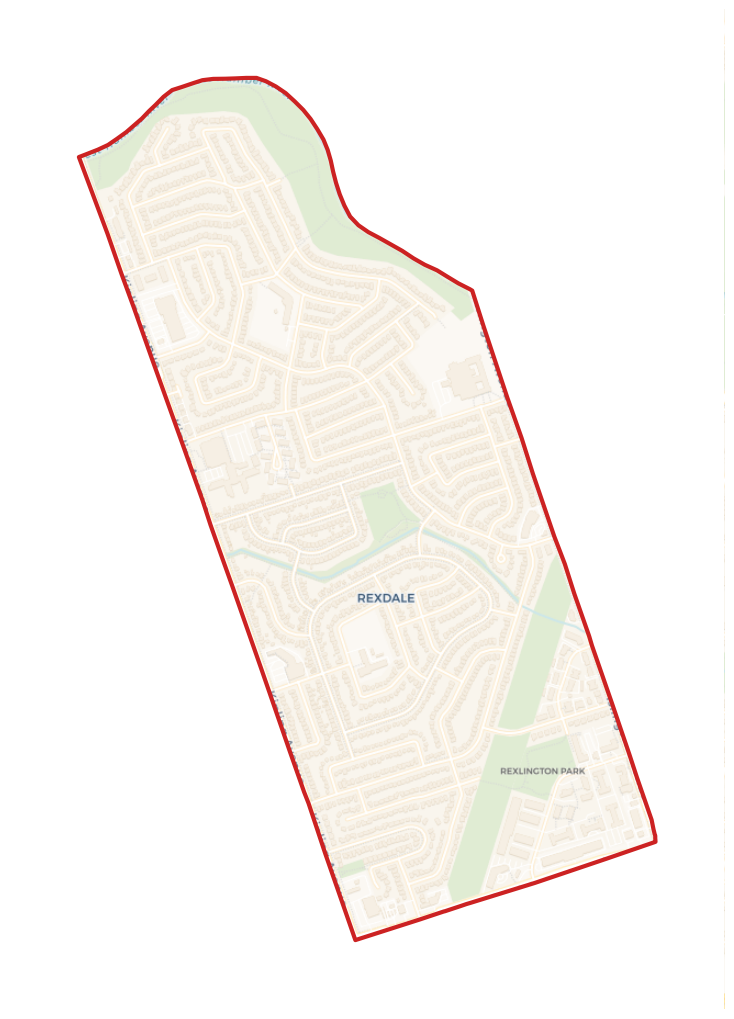

In [12]:
# Use original CRS for the zoomed basemap map (no rotation needed here)
target = gdf[gdf["AREA_NAME"] == hood].to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_facecolor("white")
target.plot(ax=ax, color="#fff8f8", edgecolor="none", zorder=1)

bounds = target.total_bounds
pad = 300
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zoom=15, zorder=2)

geom = target.geometry.iloc[0]
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
big_box = box(xmin - 1000, ymin - 1000, xmax + 1000, ymax + 1000)
mask_geom = big_box.difference(geom)

def geom_to_path(geom):
    vertices, codes = [], []
    exterior = np.array(geom.exterior.coords)
    vertices.append(exterior)
    codes.append([Path.MOVETO] + [Path.LINETO] * (len(exterior) - 2) + [Path.CLOSEPOLY])
    for interior in geom.interiors:
        coords = np.array(interior.coords)
        vertices.append(coords)
        codes.append([Path.MOVETO] + [Path.LINETO] * (len(coords) - 2) + [Path.CLOSEPOLY])
    return Path(np.concatenate(vertices), np.concatenate(codes))

path = geom_to_path(mask_geom)
patch = PathPatch(path, facecolor="white", edgecolor="white", linewidth=0, zorder=3)
ax.add_patch(patch)

target.plot(ax=ax, color="none", edgecolor="#cc2222", linewidth=3, zorder=4)
ax.margins(0)
ax.set_axis_off()
plt.tight_layout(pad=0)
# plt.savefig(f"{hood}_map.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()